## ===== Dependenses installation =====

In [24]:
!pip install numba numpy opencv-python requests

import numpy as np
import requests
import cv2
import matplotlib.pyplot as plt
from numba import cuda
from math import sqrt
import time

### Function for loading image from link

In [25]:
import requests
import numpy as np
import cv2

def get_image(url: str) -> np.ndarray:
    response = requests.get(url)
    response.raise_for_status()

    image_array = np.asarray(bytearray(response.content), dtype=np.uint8)
    img = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

    if img is None:
        raise ValueError(f"Failed to decode image from link: {url}")

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

### Get images from link

In [37]:
img = get_image("https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcSgWHO1Vpk5q0KHM9930Hly2oYsgsYxkLk7M8Ujr74HHoGsdTGkvIHt-kM&s=10")
#img = get_image("https://i.pinimg.com/736x/1f/b2/4b/1fb24be675fc92e52bfaa4e99a63ceca.jpg")
#img = get_image("https://i.pinimg.com/1200x/76/7d/56/767d566ad56b66b2518419e3cd16b332.jpg")

In [27]:
def voronoi(img_rgb, num_points=1500):
    h, w, _ = img_rgb.shape

    rect = (0, 0, w, h)
    subdiv = cv2.Subdiv2D(rect)

    points_list = []
    for _ in range(num_points):
        px = float(np.random.randint(0, w))
        py = float(np.random.randint(0, h))
        subdiv.insert((px, py))
        points_list.append((px, py))

    for pt in [(0, 0), (w - 1, 0), (0, h - 1), (w - 1, h - 1)]:
        subdiv.insert(pt)

    facets, centers = subdiv.getVoronoiFacetList([])

    out = np.zeros_like(img_rgb)

    for i in range(len(facets)):
        facet = facets[i]

        pts_np = np.array(facet, dtype=np.int32)

        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.fillConvexPoly(mask, pts_np, 255)

        mean_val = cv2.mean(img_rgb, mask=mask)
        color = (int(mean_val[0]), int(mean_val[1]), int(mean_val[2]))

        cv2.fillConvexPoly(out, pts_np, color)

    return out

In [28]:
@cuda.jit
def get_pixel_gray(d_img, x, y):
    return 0.299 * d_img[y, x, 0] + 0.587 * d_img[y, x, 1] + 0.114 * d_img[y, x, 2]

@cuda.jit
def do_device_find_contour_pixels(d_img, d_points, d_count, h, w):
    start_x, start_y = cuda.grid(2)

    stride_x = cuda.blockDim.x * cuda.gridDim.x
    stride_y = cuda.blockDim.y * cuda.gridDim.y

    for y in range(start_y + 1, h - 1, stride_y):
        for x in range(start_x + 1, w -1, stride_x):

            p00 = get_pixel_gray(d_img, x - 1, y - 1)
            p01 = get_pixel_gray(d_img, x,     y - 1)
            p02 = get_pixel_gray(d_img, x + 1, y - 1)
            p10 = get_pixel_gray(d_img, x - 1, y    )
            p11 = get_pixel_gray(d_img, x,     y    )
            p12 = get_pixel_gray(d_img, x + 1, y    )
            p20 = get_pixel_gray(d_img, x - 1, y + 1)
            p21 = get_pixel_gray(d_img, x,     y + 1)
            p22 = get_pixel_gray(d_img, x + 1, y + 1)

            gx = -p00 + p02 - 2.0 * p10 + 2.0 * p12 - p20 + p22
            gy = -p00 - 2.0 * p01 - p02 + p20 + 2.0 * p21 + p22

            lightness = sqrt(gx*gx + gy*gy)

            if lightness >= 240:
                idx = cuda.atomic.add(d_count, 0, 1)
                d_points[idx, 0] = x
                d_points[idx, 1] = y

In [29]:
def get_vertexes_of_Delone_Triangulation(img, num_points=1500):
    h, w, _ = img.shape

    d_img = cuda.to_device(img.astype(np.float32))
    d_points = cuda.device_array((h * w, 2), dtype=np.float32)
    d_count = cuda.to_device(np.zeros(1, dtype=np.int32))

    threads_per_block = (16, 16)
    blocks_per_grid = (16, 16)

    do_device_find_contour_pixels[blocks_per_grid, threads_per_block](
        d_img, d_points, d_count, h , w
    )

    rect = (0, 0, w, h)
    n_edge = int(num_points / 16)
    n_rand = num_points - n_edge

    count = d_count.copy_to_host()[0]
    edge_points = d_points.copy_to_host()[:count]

    subdiv = cv2.Subdiv2D(rect)

    if len(edge_points) > 0:
        n_edge = min(n_edge, len(edge_points))
        selected_indices = np.random.choice(len(edge_points), size = n_edge, replace=False)
        chosen_edge_points = edge_points[selected_indices]
        for point in chosen_edge_points:
            subdiv.insert((float(point[0]), float(point[1])))
    else:
        n_rand = num_points

    for _ in range(n_rand):
        px = float(np.random.randint(0, w))
        py = float(np.random.randint(0, h))
        subdiv.insert((px, py))

    subdiv.insert((0.0, 0.0))
    subdiv.insert((float(w -1), 0.0))
    subdiv.insert((0.0, float(h - 1)))
    subdiv.insert((float(w - 1), float(h - 1)))

    return subdiv


def render_voronoi_mozaic(img, subdiv):
    h, w, _ = img.shape
    facets, _ = subdiv.getVoronoiFacetList([])
    out = np.zeros_like(img)

    for facet in facets:
        pts_np = np.array(facet, dtype=np.int32)
        pts_np[:, 0] = np.clip(pts_np[:, 0], 0, w - 1)
        pts_np[:, 1] = np.clip(pts_np[:, 1], 0, h - 1)

        x_rect, y_rect, w_rect, h_rect = cv2.boundingRect(pts_np)
        if w_rect <= 0 or h_rect <= 0:
            continue

        local_pts = pts_np.copy()
        local_pts[:, 0] -= x_rect
        local_pts[:, 1] -= y_rect

        mask = np.zeros((h_rect, w_rect), dtype=np.uint8)
        cv2.fillConvexPoly(mask, local_pts, 255)

        roi = img[y_rect:y_rect + h_rect, x_rect:x_rect + w_rect]
        mean_val = cv2.mean(roi, mask=mask)
        color = (int(mean_val[0]), int(mean_val[1]), int(mean_val[2]))

        cv2.fillConvexPoly(out, pts_np, color)

    return out

def voronoi_mozaic_cuda(img, num_points=1500):
    subdiv = get_vertexes_of_Delone_Triangulation(img, num_points)
    result = render_voronoi_mozaic(img, subdiv)
    return result

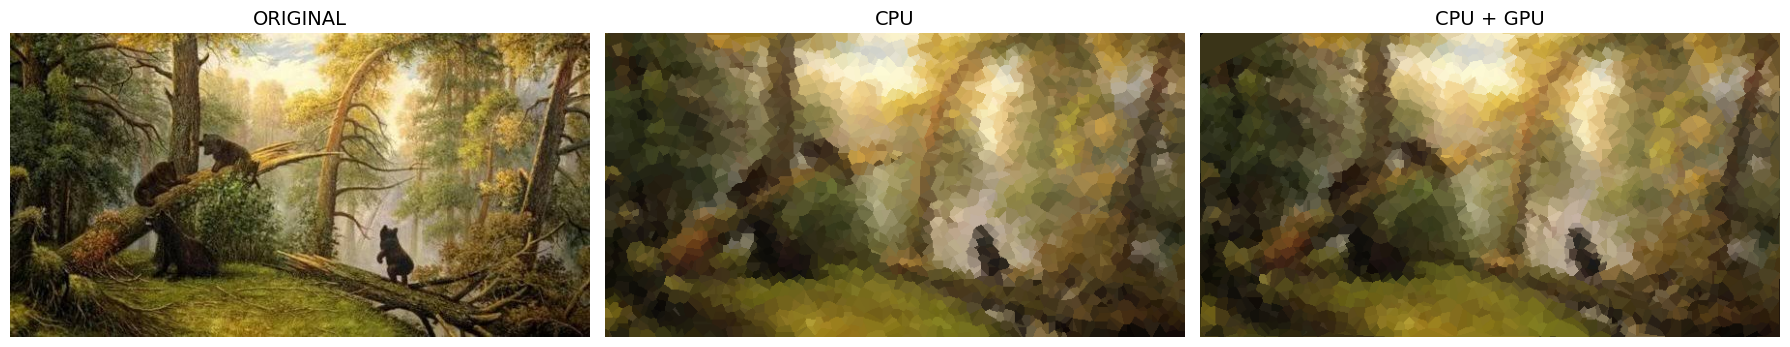

In [38]:
res_device = voronoi_mozaic_cuda(img, num_points=3000)
res_host = voronoi(img, num_points=3000)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("ORIGINAL", fontsize=14)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(res_host)
plt.title("CPU", fontsize=14)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(res_device)
plt.title("CPU + GPU", fontsize=14)
plt.axis("off")

plt.tight_layout()
plt.show()

Count  500
Count  1000
Count  1500
Count  2000
Count  2500
Count  3000
Count  3500
Count  4000
Count  4500
Count  5000


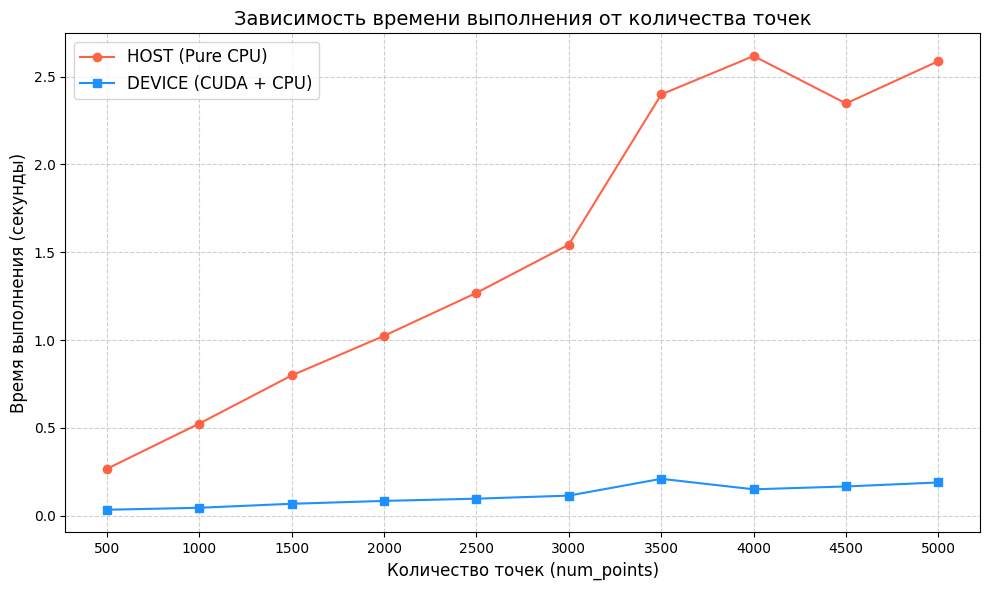

In [31]:
points_quantities = [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000]

host_times = []
device_times = []

for n in points_quantities:
  start = time.perf_counter()
  _ = voronoi(img, num_points=n)
  host_times.append(time.perf_counter() - start)

  start = time.perf_counter()
  _ = voronoi_mozaic_cuda(img, num_points=n)
  device_times.append(time.perf_counter() - start)

  print("Count ", n)


plt.figure(figsize=(10, 6))
plt.plot(points_quantities, host_times, marker='o', linestyle='-', label='HOST (Pure CPU)', color='tomato')
plt.plot(points_quantities, device_times, marker='s', linestyle='-', label='DEVICE (CUDA + CPU)', color='dodgerblue')

plt.title("Зависимость времени выполнения от количества точек", fontsize=14)
plt.xlabel("Количество точек (num_points)", fontsize=12)
plt.ylabel("Время выполнения (секунды)", fontsize=12)
plt.xticks(points_quantities)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

